In [ ]:
# Machine Learning Models - Supermarket Analysis
This notebook applies multiple machine learning algorithms to classify pricing patterns and evaluate model performance.

In [5]:
import pandas as pd
df = pd.read_csv("../data/processed/cleaned_data.csv")
print(df.columns)

Index(['supermarket', 'prices_(£)', 'prices_unit_(£)', 'unit', 'names', 'date',
       'category', 'own_brand', 'year', 'month', 'day', 'dayofweek'],
      dtype='object')


In [2]:
# ================================
# IMPORTS
# ================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import DecisionTreeRegressor

# ================================
# LOAD DATA
# ================================
df = pd.read_csv("../data/processed/cleaned_data.csv")

# ================================
# SMALL SAMPLE (VERY FAST)
# ================================
df = df.sample(n=2000, random_state=42)

# ================================
# DROP HEAVY COLUMNS
# ================================
df = df.drop(columns=["names", "date"])

# ================================
# SIMPLE ENCODING (NO DUMMIES)
# ================================
# Convert categories to numbers (FAST)
for col in ["supermarket", "category", "own_brand", "unit"]:
    df[col] = df[col].astype("category").cat.codes

# ================================
# TARGET & FEATURES
# ================================
y = df["prices_(£)"]
X = df.drop(columns=["prices_(£)"])

# ================================
# TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# FAST MODELS ONLY
# ================================
models = {
    "Decision Tree": DecisionTreeRegressor(max_depth=6),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=20,   # very small → fast
        max_depth=8,
        n_jobs=-1,
        random_state=42
    )
}

# ================================
# TRAINING
# ================================
for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    print(f"\n{name}")
    print(f"MAE: {mae:.3f}")
    print(f"RMSE: {rmse:.3f}")
    print(f"R2 Score: {r2:.3f}")


Decision Tree
MAE: 2.241
RMSE: 4.597
R2 Score: 0.381

Random Forest
MAE: 1.942
RMSE: 3.901
R2 Score: 0.554


In [1]:
pip install category_encoders xgboost

Note: you may need to restart the kernel to use updated packages.


In [3]:
# ================================
# IMPORTS
# ================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor

# Target Encoding
from category_encoders import TargetEncoder

# ================================
# LOAD DATA
# ================================
df = pd.read_csv("../data/processed/cleaned_data.csv")

# ================================
# SAMPLE (FAST)
# ================================
df = df.sample(n=3000, random_state=42)

# ================================
# DROP HEAVY COLUMNS
# ================================
df = df.drop(columns=["date", "names"])

# ================================
# TARGET
# ================================
y = df["prices_(£)"]
X = df.drop(columns=["prices_(£)"])

# ================================
# TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# TARGET ENCODING (SMART ENCODING)
# ================================
cat_cols = ["supermarket", "category", "unit", "own_brand"]

encoder = TargetEncoder(cols=cat_cols)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols], y_train)
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

# ================================
# FEATURE SELECTION (REMOVE WEAK FEATURES)
# ================================
# Correlation with target
corr = X_train.copy()
corr["target"] = y_train

corr_values = corr.corr()["target"].abs().sort_values(ascending=False)

# Select top features
top_features = corr_values.index[1:8]  # top 7 features

X_train = X_train[top_features]
X_test = X_test[top_features]

print("\nSelected Features:\n", list(top_features))

# ================================
# MODELS (FAST + STRONG)
# ================================
models = {
    "Linear Regression": LinearRegression(),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        max_depth=10,
        n_jobs=-1,
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=50
    ),
    
    "XGBoost": XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        n_jobs=-1,
        random_state=42,
        verbosity=0
    )
}

results = []

# ================================
# TRAINING & EVALUATION
# ================================
for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append([name, mae, rmse, r2])
    
    print(f"{name} DONE")

# ================================
# RESULTS TABLE
# ================================
results_df = pd.DataFrame(results, columns=[
    "Model", "MAE", "RMSE", "R2 Score"
])

# Sort by best model
results_df = results_df.sort_values(by="R2 Score", ascending=False)

print("\nFINAL RESULTS:\n")
print(results_df)


Selected Features:
 ['category', 'unit', 'own_brand', 'supermarket', 'prices_unit_(£)', 'year', 'month']
Linear Regression DONE
Random Forest DONE
Gradient Boosting DONE
XGBoost DONE

FINAL RESULTS:

               Model       MAE      RMSE  R2 Score
3            XGBoost  1.929011  4.579642  0.633237
1      Random Forest  1.858732  4.584061  0.632529
2  Gradient Boosting  2.214335  4.893834  0.581187
0  Linear Regression  3.440631  6.797779  0.191917


In [5]:
pip install shap

INFO: pip is looking at multiple versions of numba to determine which version is compatible with other requirements. This could take a while.
     ---------------------------------------- 0.0/60.8 kB ? eta -:--:--
     -------------------- ------------------- 30.7/60.8 kB 1.3 MB/s eta 0:00:01
     ---------------------------------------- 60.8/60.8 kB 1.1 MB/s eta 0:00:00
   ---------------------------------------- 0.0/556.1 kB ? eta -:--:--
   ----- ---------------------------------- 71.7/556.1 kB 2.0 MB/s eta 0:00:01
   -------------- ------------------------- 204.8/556.1 kB 2.1 MB/s eta 0:00:01
   -------------------------- ------------- 368.6/556.1 kB 2.5 MB/s eta 0:00:01
   ------------------------------------ --- 501.8/556.1 kB 2.6 MB/s eta 0:00:01
   ---------------------------------------- 556.1/556.1 kB 2.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   - -------------------------------------- 0.1/2.8 MB 3.0 MB/s eta 0:00:01
   --- ----

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
contourpy 1.2.0 requires numpy<2.0,>=1.20, but you have numpy 2.2.6 which is incompatible.
pywavelets 1.5.0 requires numpy<2.0,>=1.22.4, but you have numpy 2.2.6 which is incompatible.
streamlit 1.32.0 requires numpy<2,>=1.19.3, but you have numpy 2.2.6 which is incompatible.


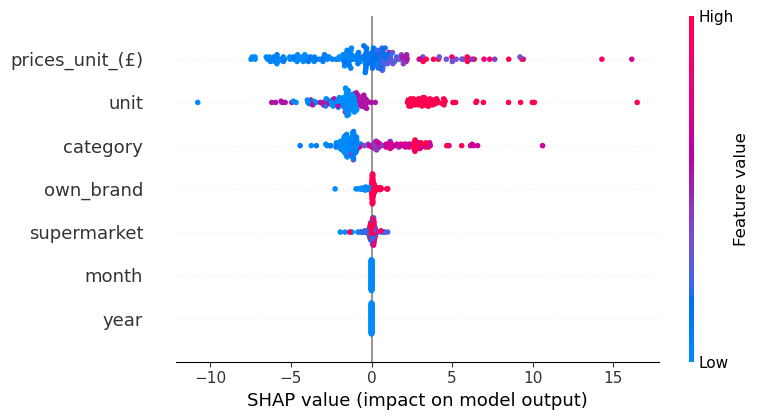

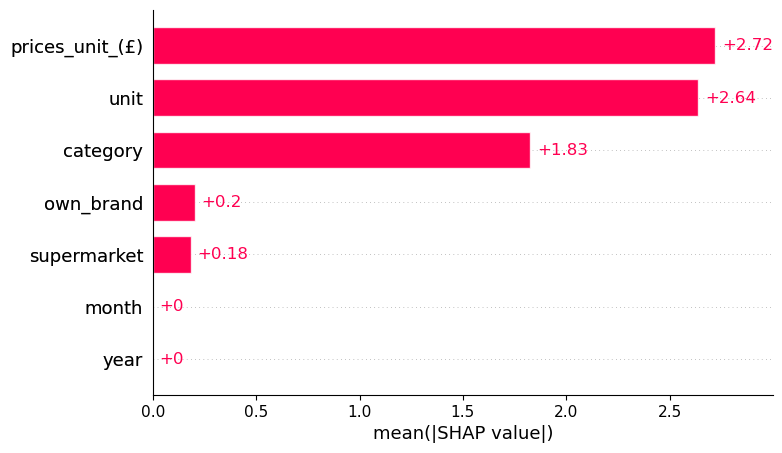

In [7]:
# ================================
# SHAP EXPLAINABILITY (XGBOOST)
# ================================
import shap

# Fit model (if not already fitted)
xgb_model = models["XGBoost"]
xgb_model.fit(X_train, y_train)

# Create explainer
explainer = shap.Explainer(xgb_model)

# Compute SHAP values (small sample for speed)
X_sample = X_test.sample(200, random_state=42)
shap_values = explainer(X_sample)

# ================================
# SHAP SUMMARY PLOT
# ================================
shap.summary_plot(shap_values, X_sample)

# ================================
# SHAP FEATURE IMPORTANCE
# ================================
shap.plots.bar(shap_values)

In [9]:
# ================================
# HYPERPARAMETER TUNING (XGBOOST)
# ================================
from sklearn.model_selection import GridSearchCV
from xgboost import XGBRegressor

param_grid = {
    "n_estimators": [50, 100],
    "max_depth": [4, 6],
    "learning_rate": [0.05, 0.1]
}

xgb = XGBRegressor(n_jobs=-1, random_state=42, verbosity=0)

grid = GridSearchCV(
    estimator=xgb,
    param_grid=param_grid,
    cv=3,
    scoring="r2",
    verbose=1
)

grid.fit(X_train, y_train)

# Best model
best_xgb = grid.best_estimator_

print("\nBest Parameters:", grid.best_params_)

# Evaluate
y_pred = best_xgb.predict(X_test)

from sklearn.metrics import r2_score
print("Tuned R2 Score:", r2_score(y_test, y_pred))

Fitting 3 folds for each of 8 candidates, totalling 24 fits

Best Parameters: {'learning_rate': 0.05, 'max_depth': 6, 'n_estimators': 50}
Tuned R2 Score: 0.6000128944544656


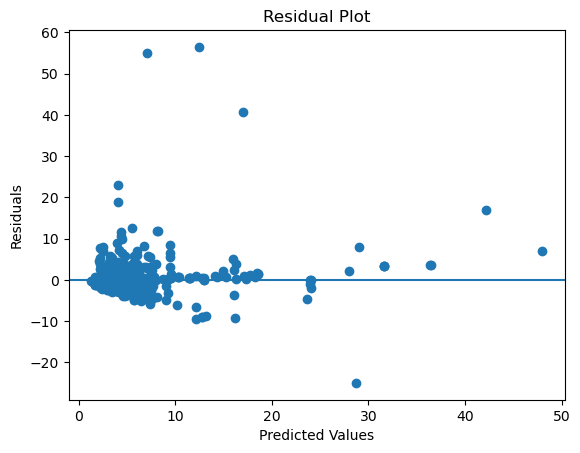

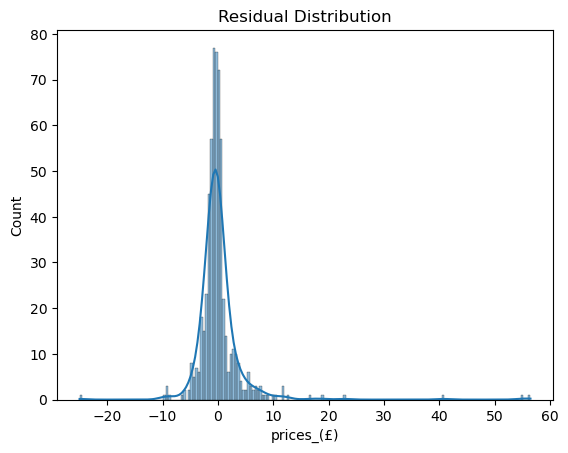

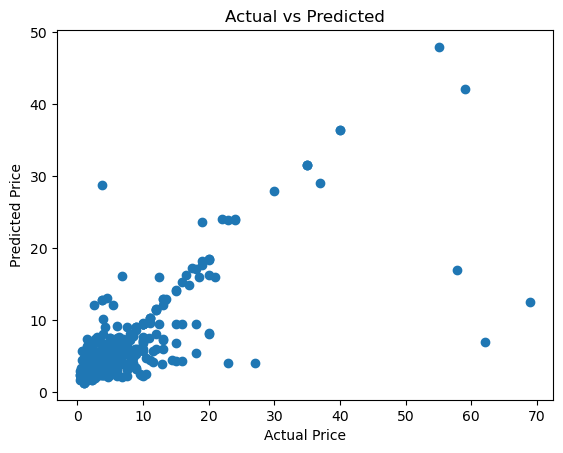

In [11]:
# ================================
# RESIDUAL ANALYSIS (XGBOOST)
# ================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predictions
y_pred = best_xgb.predict(X_test)

# Residuals
residuals = y_test - y_pred

# ================================
# RESIDUAL SCATTER PLOT
# ================================
plt.figure()
plt.scatter(y_pred, residuals)
plt.axhline(y=0)
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

# ================================
# DISTRIBUTION OF RESIDUALS
# ================================
plt.figure()
sns.histplot(residuals, kde=True)
plt.title("Residual Distribution")
plt.show()

# ================================
# ACTUAL vs PREDICTED
# ================================
plt.figure()
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")
plt.show()

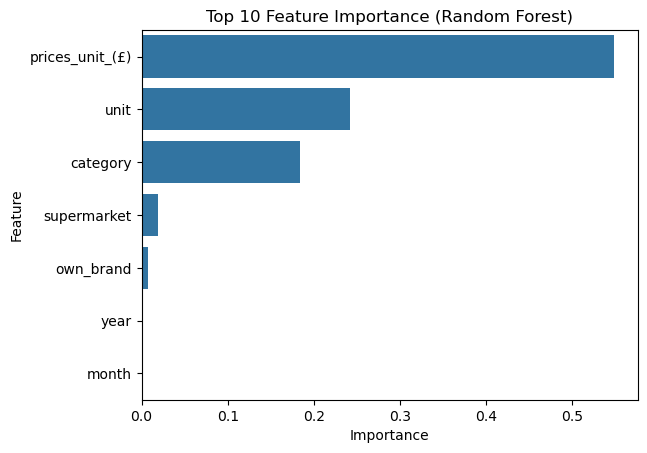

In [13]:
# ================================
# RANDOM FOREST FEATURE IMPORTANCE
# ================================
rf_model = models["Random Forest"]
rf_model.fit(X_train, y_train)

importances = rf_model.feature_importances_
features = X_train.columns

feat_df = pd.DataFrame({
    "Feature": features,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Top 10 features
top_features = feat_df.head(10)

# ================================
# PLOT
# ================================
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure()
sns.barplot(x="Importance", y="Feature", data=top_features)
plt.title("Top 10 Feature Importance (Random Forest)")
plt.show()

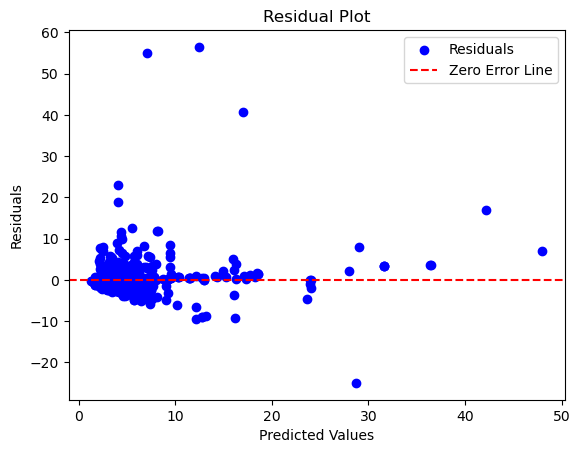

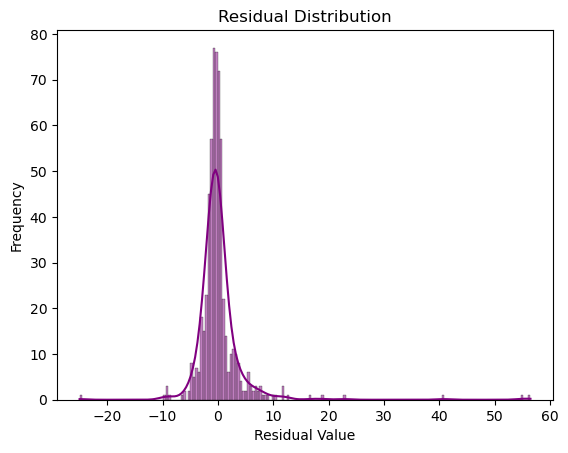

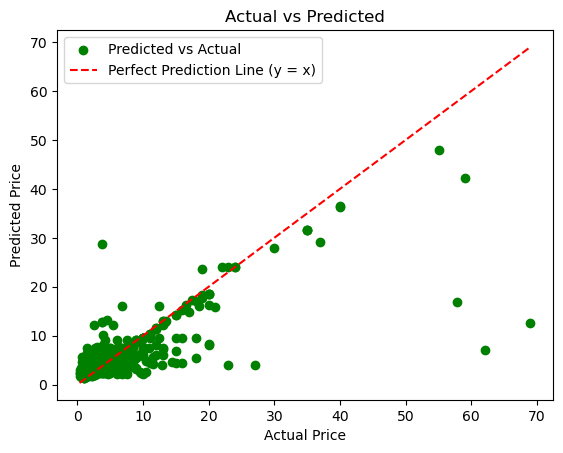

In [15]:
# ================================
# RESIDUAL ANALYSIS (ENHANCED)
# ================================
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predictions
y_pred = best_xgb.predict(X_test)

# Residuals
residuals = y_test - y_pred

# ================================
# RESIDUAL SCATTER PLOT
# ================================
plt.figure()

plt.scatter(y_pred, residuals, color="blue", label="Residuals")

# Zero error line
plt.axhline(y=0, color="red", linestyle="--", label="Zero Error Line")

plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.legend()  # 🔥 Shows color meaning
plt.show()

# ================================
# DISTRIBUTION OF RESIDUALS
# ================================
plt.figure()

sns.histplot(residuals, kde=True, color="purple")

plt.title("Residual Distribution")
plt.xlabel("Residual Value")
plt.ylabel("Frequency")

plt.show()

# ================================
# ACTUAL vs PREDICTED (ENHANCED)
# ================================
plt.figure()

# Scatter points
plt.scatter(y_test, y_pred, color="green", label="Predicted vs Actual")

# Perfect prediction line
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())

plt.plot(
    [min_val, max_val],
    [min_val, max_val],
    color="red",
    linestyle="--",
    label="Perfect Prediction Line (y = x)"
)

plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted")

plt.legend()  # 🔥 shows what each color/line means
plt.show()

In [1]:
# ================================
# IMPORTS
# ================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor

from category_encoders import TargetEncoder

# ================================
# LOAD DATA
# ================================
df = pd.read_csv("../data/processed/cleaned_data.csv")

# ================================
# SAMPLE (FAST)
# ================================
df = df.sample(n=3000, random_state=42)

# ================================
# DROP UNUSED COLUMNS
# ================================
df = df.drop(columns=["date", "names"])

# ================================
# TARGET & FEATURES
# ================================
y = df["prices_(£)"]
X = df.drop(columns=["prices_(£)"])

# ================================
# TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# TARGET ENCODING
# ================================
cat_cols = ["supermarket", "category", "unit", "own_brand"]

encoder = TargetEncoder(cols=cat_cols)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols], y_train)
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

# ================================
# FEATURE SELECTION
# ================================
corr = X_train.copy()
corr["target"] = y_train

corr_values = corr.corr()["target"].abs().sort_values(ascending=False)
top_features = corr_values.index[1:8]

X_train = X_train[top_features]
X_test = X_test[top_features]

print("\nSelected Features:\n", list(top_features))

# ================================
# MODELS
# ================================
models = {
    "Linear Regression": LinearRegression(),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        max_depth=10,
        n_jobs=-1,
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=50
    ),
    
    "XGBoost": XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        n_jobs=-1,
        random_state=42,
        verbosity=0
    )
}

results = []

# ================================
# STORE COMBINED PREDICTIONS
# ================================
all_predictions = pd.DataFrame({
    "actual": y_test.reset_index(drop=True)
})

# ================================
# TRAINING & EVALUATION
# ================================
for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Store predictions
    col_name = name.replace(" ", "_").lower() + "_pred"
    all_predictions[col_name] = y_pred
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append([name, mae, rmse, r2])
    
    print(f"{name} DONE")

# ================================
# RESULTS TABLE
# ================================
results_df = pd.DataFrame(results, columns=[
    "Model", "MAE", "RMSE", "R2 Score"
])

results_df = results_df.sort_values(by="R2 Score", ascending=False)

print("\nFINAL RESULTS:\n")
print(results_df)

# ================================
# EXPORT FILES
# ================================

# Combined predictions (ALL models)
all_predictions.to_csv("ml_combined_predictions.csv", sep=";", index=False)

# Model performance
results_df.to_csv("model_performance.csv", index=False)

print("\n✅ Files saved successfully!")
print(" - ml_combined_predictions.csv")
print(" - model_performance.csv")

ImportError: cannot import name 'Tags' from 'sklearn.utils' (C:\Users\anuja\anaconda3\Lib\site-packages\sklearn\utils\__init__.py)

In [3]:
pip install category_encoders==2.6.3

   ---------------------------------------- 0.0/81.9 kB ? eta -:--:--
   ----- ---------------------------------- 10.2/81.9 kB ? eta -:--:--
   -------------------- ------------------- 41.0/81.9 kB 393.8 kB/s eta 0:00:01
   ---------------------------------------- 81.9/81.9 kB 657.0 kB/s eta 0:00:00
  Attempting uninstall: category_encoders
    Found existing installation: category_encoders 2.9.0
    Uninstalling category_encoders-2.9.0:
      Successfully uninstalled category_encoders-2.9.0
Note: you may need to restart the kernel to use updated packages.


In [5]:
import category_encoders
import sklearn

print(category_encoders.__version__)
print(sklearn.__version__)

2.6.3
1.4.2


In [11]:
pip install scikit-learn==1.3.2

Note: you may need to restart the kernel to use updated packages.


In [13]:
import category_encoders
import sklearn

print(category_encoders.__version__)
print(sklearn.__version__)

2.6.3
1.4.2


In [15]:
# ================================
# IMPORTS
# ================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from xgboost import XGBRegressor

from category_encoders import TargetEncoder

# ================================
# LOAD DATA
# ================================
df = pd.read_csv("../data/processed/cleaned_data.csv")

# ================================
# SAMPLE (FAST)
# ================================
df = df.sample(n=3000, random_state=42)

# ================================
# DROP UNUSED COLUMNS
# ================================
df = df.drop(columns=["date", "names"])

# ================================
# TARGET & FEATURES
# ================================
y = df["prices_(£)"]
X = df.drop(columns=["prices_(£)"])

# ================================
# TRAIN TEST SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# ================================
# TARGET ENCODING
# ================================
cat_cols = ["supermarket", "category", "unit", "own_brand"]

encoder = TargetEncoder(cols=cat_cols)

X_train[cat_cols] = encoder.fit_transform(X_train[cat_cols], y_train)
X_test[cat_cols] = encoder.transform(X_test[cat_cols])

# ================================
# FEATURE SELECTION
# ================================
corr = X_train.copy()
corr["target"] = y_train

corr_values = corr.corr()["target"].abs().sort_values(ascending=False)
top_features = corr_values.index[1:8]

X_train = X_train[top_features]
X_test = X_test[top_features]

print("\nSelected Features:\n", list(top_features))

# ================================
# MODELS
# ================================
models = {
    "Linear Regression": LinearRegression(),
    
    "Random Forest": RandomForestRegressor(
        n_estimators=50,
        max_depth=10,
        n_jobs=-1,
        random_state=42
    ),
    
    "Gradient Boosting": GradientBoostingRegressor(
        n_estimators=50
    ),
    
    "XGBoost": XGBRegressor(
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        n_jobs=-1,
        random_state=42,
        verbosity=0
    )
}

results = []

# ================================
# STORE COMBINED PREDICTIONS
# ================================
all_predictions = pd.DataFrame({
    "actual": y_test.reset_index(drop=True)
})

# ================================
# TRAINING & EVALUATION
# ================================
for name, model in models.items():
    
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Store predictions
    col_name = name.replace(" ", "_").lower() + "_pred"
    all_predictions[col_name] = y_pred
    
    # Metrics
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2 = r2_score(y_test, y_pred)
    
    results.append([name, mae, rmse, r2])
    
    print(f"{name} DONE")

# ================================
# RESULTS TABLE
# ================================
results_df = pd.DataFrame(results, columns=[
    "Model", "MAE", "RMSE", "R2 Score"
])

results_df = results_df.sort_values(by="R2 Score", ascending=False)

print("\nFINAL RESULTS:\n")
print(results_df)

# ================================
# EXPORT FILES
# ================================

# Combined predictions (ALL models)
all_predictions.to_csv("ml_combined_predictions.csv", sep=";", index=False)

# Model performance
results_df.to_csv("model_performance.csv", index=False)

print("\n✅ Files saved successfully!")
print(" - ml_combined_predictions.csv")
print(" - model_performance.csv")

C:\Users\anuja\anaconda3\Lib\site-packages\category_encoders\ordinal.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[column] = X[column].astype("object").fillna(np.nan).map(col_mapping)
C:\Users\anuja\anaconda3\Lib\site-packages\category_encoders\ordinal.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X[column] = X[column].astype("object").fillna(np.nan).map(col_mapping)
C:\Users\anuja\anaconda3\Lib\site-packages\category_encoders\ordinal.py:198: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and wil


Selected Features:
 ['category', 'unit', 'own_brand', 'supermarket', 'prices_unit_(£)', 'year', 'month']
Linear Regression DONE
Random Forest DONE
Gradient Boosting DONE
XGBoost DONE

FINAL RESULTS:

               Model       MAE      RMSE  R2 Score
3            XGBoost  1.929011  4.579642  0.633237
1      Random Forest  1.858732  4.584061  0.632529
2  Gradient Boosting  2.214512  4.894215  0.581122
0  Linear Regression  3.440631  6.797779  0.191917

✅ Files saved successfully!
 - ml_combined_predictions.csv
 - model_performance.csv
